In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
import os
from dotenv import load_dotenv

In [5]:
load_dotenv()

True

In [6]:
model = ChatGroq(
    model='openai/gpt-oss-120b',
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.5
)

In [7]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [8]:
def create_outline(state: BlogState) -> BlogState:
    
    # fetch the title
    title = state['title']

    # call llm and generate outline
    prompt = f"Generate a detailed outline for a blog on the topic {title}"
    outline = model.invoke(prompt).content

    # update the state
    state['outline'] = outline

    return state


In [9]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f"Write a detailed blog on the title {title} using the following outline \n {outline}"

    content = model.invoke(prompt).content

    state['content'] = content
    
    return state

In [10]:
graph = StateGraph(BlogState)

# Add Nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# Add Edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

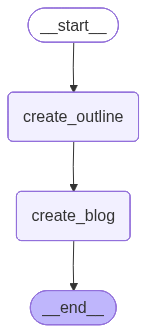

In [11]:
workflow

In [12]:
initial_state = {'title':'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '**Blog Title:** *The Rise of AI in India: Opportunities, Challenges, and the Road Ahead*\n\n---\n\n## 1. Introduction (≈300‑400 words)  \n- **Hook:** A striking statistic or anecdote (e.g., “India’s AI market is projected to hit $17\u202fbillion by 2027”).  \n- **Why It Matters:** Briefly explain AI’s global significance and why India is uniquely positioned to become a leader.  \n- **Thesis Statement:** Outline the blog’s focus – exploring the drivers behind AI’s growth in India, the ecosystems supporting it, the impact across sectors, and the challenges that must be addressed.\n\n---\n\n## 2. Historical Context: From Early Adoption to Momentum (≈400‑500 words)  \n### 2.1 Early Foundations  \n- 1950s‑70s: Pioneering computer science programs (IITs, IISc).  \n- 1990s‑2000s: Government IT initiatives (e‑Gov, NIC).  \n\n### 2.2 The Turning Point (2015‑2020)  \n- Launch of **NITI Aayog’s AI Strategy (2018)**.  \n- Formation of **Centre for Artif

In [13]:
print(final_state['outline'])

**Blog Title:** *The Rise of AI in India: Opportunities, Challenges, and the Road Ahead*

---

## 1. Introduction (≈300‑400 words)  
- **Hook:** A striking statistic or anecdote (e.g., “India’s AI market is projected to hit $17 billion by 2027”).  
- **Why It Matters:** Briefly explain AI’s global significance and why India is uniquely positioned to become a leader.  
- **Thesis Statement:** Outline the blog’s focus – exploring the drivers behind AI’s growth in India, the ecosystems supporting it, the impact across sectors, and the challenges that must be addressed.

---

## 2. Historical Context: From Early Adoption to Momentum (≈400‑500 words)  
### 2.1 Early Foundations  
- 1950s‑70s: Pioneering computer science programs (IITs, IISc).  
- 1990s‑2000s: Government IT initiatives (e‑Gov, NIC).  

### 2.2 The Turning Point (2015‑2020)  
- Launch of **NITI Aayog’s AI Strategy (2018)**.  
- Formation of **Centre for Artificial Intelligence and Robotics (CAIR)** and **AI research labs** at

In [15]:
print(final_state['content'])

**Blog Title:** *The Rise of AI in India: Opportunities, Challenges, and the Road Ahead*  

---

## 1. Introduction  *(≈350 words)*  

> **“India’s artificial‑intelligence market is projected to hit **$17 billion** by 2027, growing at a compound annual growth rate of 30 %.”** – IDC, 2024  

That headline‑grabbing number is more than a statistic; it is a signal that the world’s second‑largest democracy is moving from being a **consumer of AI** to becoming a **creator and exporter** of the technology.  

Artificial intelligence is no longer a futuristic buzzword. From self‑driving cars in Silicon Valley to AI‑powered diagnostics in Nairobi, the technology is reshaping economies, public services, and everyday life. For a country that already boasts a **young, English‑proficient workforce**, a **digital‑first public‑service architecture**, and a **vibrant startup ecosystem**, the timing could not be better.  

This blog explores the forces that are propelling AI’s meteoric rise in India, t

In [16]:
print(final_state['title'])

Rise of AI in India
